<a href="https://colab.research.google.com/github/AJULUMEL/PCVK25_3F_07/blob/main/week6_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : DANDI AZRUL SYAHPUTRA

KELAS : TI - 3F

NO.ABSEN : 07

**D. PRAKTIKUM FILTER**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [ ]:
# Konvulasi Citra
def convolution2d(image, kernel, stride=1, padding=0):
    # Get image and kernel dimensions
    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Flip the kernel (for convolution)
    kernel = np.flipud(np.fliplr(kernel))

    # Add padding to the image
    if padding > 0:
        image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    else:
        image_padded = image

    # Calculate the dimensions of the output
    output_h = (image_h + 2 * padding - kernel_h) // stride + 1
    output_w = (image_w + 2 * padding - kernel_w) // stride + 1

    # Initialize the output matrix
    output = np.zeros((output_h, output_w))

    # Perform the convolution operation
    for y in range(0, output_h):
        for x in range(0, output_w):
            # Extract the region of interest from the image
            y_start, x_start = y * stride, x * stride
            y_end, x_end = y_start + kernel_h, x_start + kernel_w
            region = image_padded[y_start:y_end, x_start:x_end]

            # Perform element-wise multiplication and sum
            output[y, x] = np.sum(region * kernel)

    return output

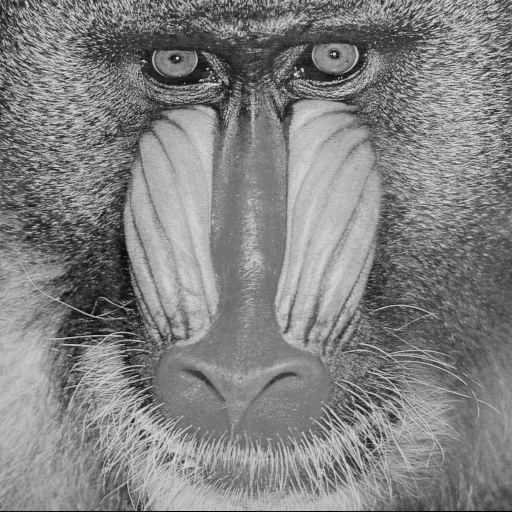

In [ ]:
img = cv.imread ('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_07/Pertemuan 6/mandrill.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv2_imshow(img)

**SHARPEN**

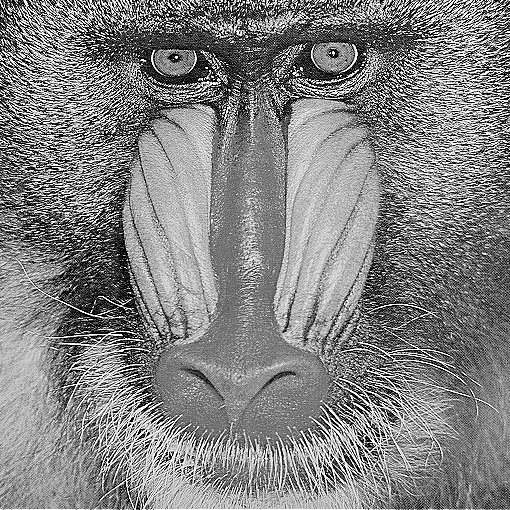

In [ ]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
img_sharpen = convolution2d(img, kernel_sharpen, stride=1, padding=0)
cv2_imshow(img_sharpen)

**EMBOSS**

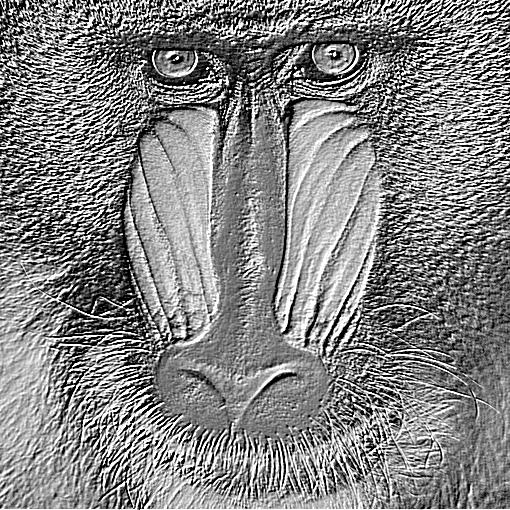

In [ ]:
kernel_embos = np.array([[-2,-1,0],
                        [-1,1,1],
                        [0,1,2]])
img_sharpen = convolution2d(img, kernel_embos, stride=1, padding=0)
cv2_imshow(img_sharpen)

**LEFT SOBEL EDGE DETECTION**

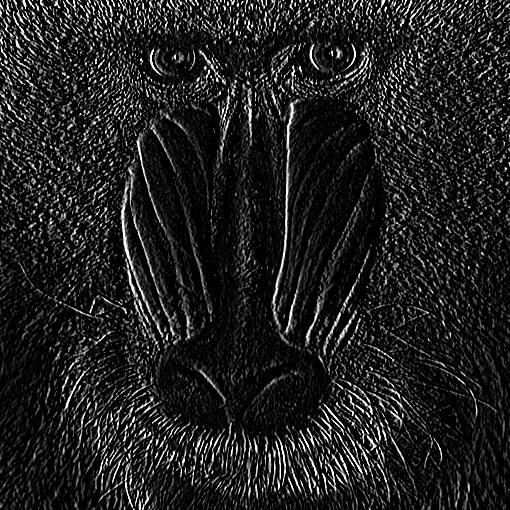

In [ ]:
kernel_edge = np.array([[1,0,-1],
                        [2,0,-2],
                        [1,0,-1]])
img_sharpen = convolution2d(img, kernel_edge, stride=1, padding=0)
cv2_imshow(img_sharpen)

**CANNY EDGE DETECTION**

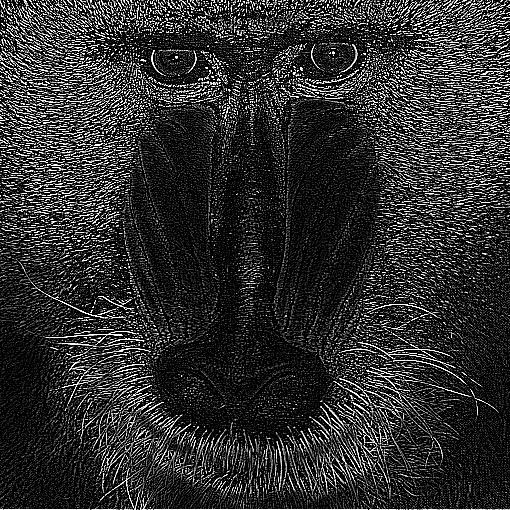

In [ ]:
kernel_canny = np.array([[-1, -1, -1],
                           [-1,8,-1],
                           [-1, -1, -1]])
img_sharpen = convolution2d(img, kernel_canny, stride=1, padding=0)
cv2_imshow(img_sharpen)

**21X21 GAUSSIAN BLUR**

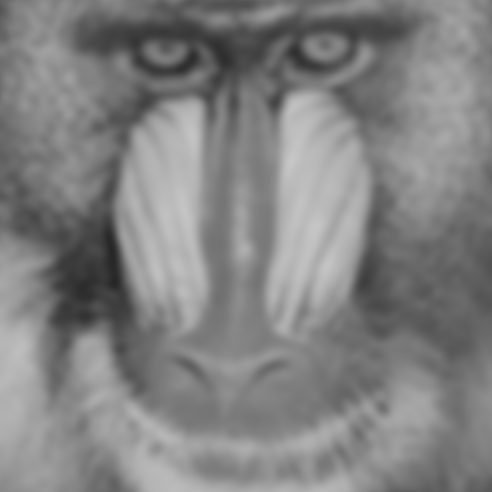

In [ ]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size,sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.T

output_gauss = convolution2d(img, gauss_kernel, stride=1, padding=0)
cv2_imshow(output_gauss)

**E. FILTER LIBRARY DAN FILTER MODERN**

**PERCOBAAN 1**

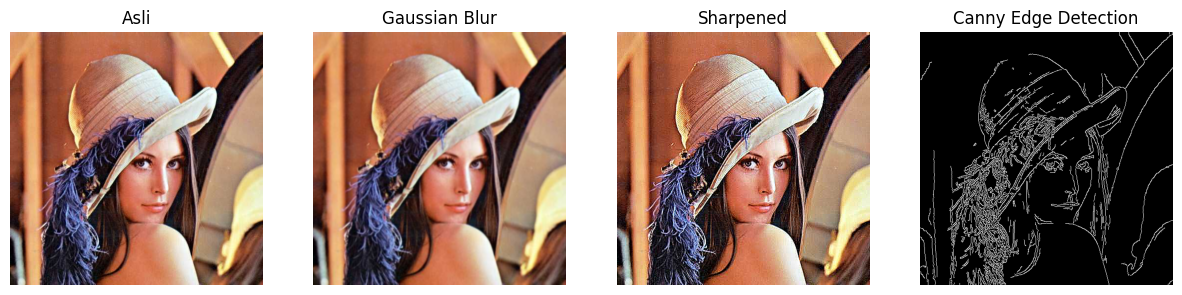

In [39]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/Colab Notebooks/Pertemuan 5/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])